# pymicromegas Demo

This notebook demonstrates a real relic density calculation with the bundled micrOMEGAs 7.1 source tree and the `SingletDM` sample model. The main path uses the `MicrOmegas` class; the lower-level `Project` runner is shown afterward as a compatibility check.


## 1. Check the execution environment and dependencies

Check Python, the OS, and basic commands such as `make` and a C compiler, which are needed to build and run micrOMEGAs.


In [9]:
from __future__ import annotations

import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path("/Users/gomeshun/workspace/pymicromegas")

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def run_command(command, cwd=None, check=False):
    return subprocess.run(
        command,
        cwd=cwd,
        shell=isinstance(command, str),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=check,
    )


def first_line(text):
    lines = (text or "").splitlines()
    return lines[0] if lines else ""


env_df = pd.DataFrame(
    [
        {"item": "Python", "value": sys.version.split()[0]},
        {"item": "Executable", "value": sys.executable},
        {"item": "Platform", "value": platform.platform()},
        {"item": "Repository", "value": str(REPO_ROOT)},
    ]
)

tool_rows = []
for name in ["make", "cc", "gcc", "clang", "curl", "wget"]:
    path = shutil.which(name)
    version = ""
    if path:
        probe = run_command([path, "--version"])
        version = first_line(probe.stdout) or first_line(probe.stderr)
    tool_rows.append(
        {
            "command": name,
            "available": bool(path),
            "path": path or "",
            "version": version,
        }
    )

display(env_df)
display(pd.DataFrame(tool_rows))

,item,value
0,Python,3.14.0b4
1,Executable,/Users/gomeshun/workspace/pymicromegas/.venv/b...
2,Platform,macOS-26.5-arm64-arm-64bit-Mach-O
3,Repository,/Users/gomeshun/workspace/pymicromegas


,command,available,path,version
0,make,True,/usr/bin/make,GNU Make 3.81
1,cc,True,/usr/bin/cc,Apple clang version 12.0.5 (clang-1205.0.22.9)
2,gcc,True,/usr/bin/gcc,Apple clang version 12.0.5 (clang-1205.0.22.9)
3,clang,True,/usr/bin/clang,Apple clang version 12.0.5 (clang-1205.0.22.9)
4,curl,True,/usr/bin/curl,curl 8.7.1 (x86_64-apple-darwin25.0) libcurl/8...
5,wget,False,,


## 2. Locate the micrOMEGAs source

`pymicromegas` bundles micrOMEGAs 7.1 as package data. This demo uses the local bundled source tree instead of downloading anything during notebook execution.


In [12]:
import importlib

import pymicromegas.pymicromegas as pm_core

pm_core = importlib.reload(pm_core)
MICROMEGAS_DIR = pm_core.MICROMEGAS_DIR
MICROMEGAS_VERSION = pm_core.MICROMEGAS_VERSION
MicrOmegas = pm_core.MicrOmegas
Project = pm_core.Project
PyMicrOmegas = pm_core.PyMicrOmegas

interface = PyMicrOmegas()
micromegas_dir = Path(MICROMEGAS_DIR).resolve()
source_note = f"micrOMEGAs {MICROMEGAS_VERSION} bundled under {micromegas_dir.relative_to(REPO_ROOT)}"

source_df = pd.DataFrame(
    [
        {"item": "version", "value": MICROMEGAS_VERSION},
        {"item": "source", "value": source_note},
        {"item": "path", "value": str(micromegas_dir)},
        {"item": "exists", "value": micromegas_dir.is_dir()},
        {"item": "already built", "value": interface.is_micromegas_built()},
    ]
)

display(source_df)
if not micromegas_dir.is_dir():
    raise FileNotFoundError(f"micrOMEGAs source tree is missing: {micromegas_dir}")

,item,value
0,version,7.1
1,source,micrOMEGAs 7.1 bundled under src/pymicromegas/...
2,path,/Users/gomeshun/workspace/pymicromegas/src/pym...
3,exists,True
4,already built,True


## 3. Calculate with `MicrOmegas`

Load the bundled `SingletDM` model through the class API and compute a relic density point directly through the generated shared-library bridge.


In [13]:
MODEL_NAME = "SingletDM"
PARAMETERS = {
    "Q": 100.0,
    "Mh": 125.0,
    "laS": 0.2,
    "laSH": 0.1,
    "Mdm1": 50.0,
}

model = MicrOmegas(MODEL_NAME)
ctypes_result = model.dark_omega(PARAMETERS)

candidate_name = model.lib.pymicromegas_cdm1().decode("UTF-8")
candidate_mass = model.lib.pymicromegas_mcdm1()
candidate_fraction = model.lib.pymicromegas_cdm_fraction(1)

metadata_df = pd.DataFrame(
    [
        {
            "model": MODEL_NAME,
            "candidate": candidate_name,
            "mass": candidate_mass,
            "fraction": candidate_fraction,
        }
    ]
)
result_df = pd.DataFrame([{**PARAMETERS, **ctypes_result}])

display(metadata_df)
display(result_df)

,model,candidate,mass,fraction
0,SingletDM,~x1,50.0,1.0


,Q,Mh,laS,laSH,Mdm1,Xf,Omega,err
0,100.0,125.0,0.2,0.1,50.0,23.825502,0.04583,0


## 4. Compare with the `Project` runner

Build the compatibility executable for the same model, run it through `subprocess`, and inspect the raw micrOMEGAs standard output.


In [15]:
project = Project(MODEL_NAME)
compile_process = project.compile()
run_process = project.run(PARAMETERS, flags=["OMEGA"])

print(f"model: {MODEL_NAME}")
print(f"project directory: {project.path}")
print(f"compile return code: {compile_process.returncode}")
print(f"run return code: {run_process.returncode}")
print("\n--- compile stdout ---")
print((compile_process.stdout or "").strip()[-3000:] or "(no stdout)")
if compile_process.stderr:
    print("\n--- compile stderr ---")
    print(compile_process.stderr.strip()[-3000:])
print("\n--- run stdout ---")
print(run_process.stdout)
if run_process.stderr:
    print("\n--- run stderr ---")
    print(run_process.stderr)

make main=pymicromegas_main.c
model: SingletDM
project directory: /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_7.1/SingletDM/
compile return code: 0
run return code: 0

--- compile stdout ---
/Library/Developer/CommandLineTools/usr/bin/make -C work
make[1]: Nothing to be done for `all'.
/Library/Developer/CommandLineTools/usr/bin/make -C lib
make[1]: Nothing to be done for `all'.
/Library/Developer/CommandLineTools/usr/bin/make -C ../sources
make[1]: Nothing to be done for `all'.
clang  -g -fsigned-char -std=gnu99 -fPIC   -o pymicromegas_main   pymicromegas_main.c  lib/aLib.a ../lib/micromegas.a  /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_7.1/CalcHEP_src/lib/dynamic_me.a ../lib/micromegas.a work/work_aux.a  lib/aLib.a   /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_7.1/CalcHEP_src/lib/sqme_aux.so /Users/gomeshun/workspace/pymicromegas/src/pymicromegas/micromegas_7.1/CalcHEP_src/lib/libSLHAplus.a /Users/gomeshun/workspac

## 5. Parse the `Project` output

Extract the relic density, freeze-out parameter, and contributing annihilation channels from the executable output, then compare them with the `MicrOmegas` result.


In [16]:
project_result = project.parse_omega(run_process.stdout, ["OMEGA"], with_channels=True)
summary = {key: value for key, value in project_result.items() if key != "channels"}
channels = project_result.get("channels", [])

summary_df = pd.DataFrame([{**PARAMETERS, **summary}])
channels_df = pd.DataFrame(channels)
if not channels_df.empty:
    channels_df["Br_percent"] = channels_df["Br"].str.rstrip("%").astype(float)
    channels_df = channels_df.sort_values("Br_percent", ascending=False).reset_index(
        drop=True
    )

comparison_df = pd.DataFrame(
    [
        {"method": "MicrOmegas.dark_omega", **ctypes_result},
        {"method": "Project.run + parse_omega", **summary},
    ]
)

display(summary_df)
display(
    channels_df.head(10)
    if not channels_df.empty
    else pd.DataFrame([{"message": "no channels parsed"}])
)
display(comparison_df)

,Q,Mh,laS,laSH,Mdm1,Xf,Omega
0,100.0,125.0,0.2,0.1,50.0,23.8,0.0458


,Br,in,out,Br_percent
0,80%,"(~x1, ~x1)","(b, B)",80.0
1,8%,"(~x1, ~x1)","(l, L)",8.0
2,7%,"(~x1, ~x1)","(G, G)",7.0
3,4%,"(~x1, ~x1)","(c, C)",4.0


,method,Xf,Omega,err
0,MicrOmegas.dark_omega,23.825502,0.04583,0.0
1,Project.run + parse_omega,23.800000,0.04580,NaN


## 6. Change parameters and rerun

Vary `Mdm1` over several values and recalculate the relic density through the `MicrOmegas` class.


In [17]:
scan_rows = []
for mdm1 in [45.0, 50.0, 55.0, 60.0, 65.0]:
    point = {**PARAMETERS, "Mdm1": mdm1}
    result = model.dark_omega(point)
    scan_rows.append(
        {
            "Mdm1": mdm1,
            "Omega": result["Omega"],
            "Xf": result["Xf"],
            "err": result["err"],
        }
    )

scan_df = pd.DataFrame(scan_rows)
display(scan_df)

,Mdm1,Omega,Xf,err
0,45.0,0.090284,22.584112,0
1,50.0,0.045830,23.825502,0
2,55.0,0.005518,27.051377,0
3,60.0,0.000048,31.359725,0
4,65.0,0.005432,25.271155,0


## 7. Visualize the results

Plot how the relic density changes as a function of `Mdm1`.


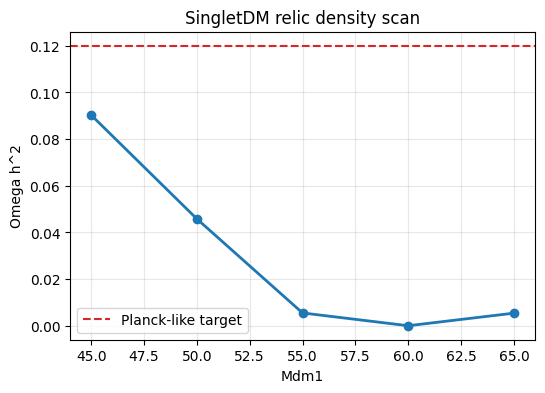

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scan_df["Mdm1"], scan_df["Omega"], marker="o", linewidth=2)
ax.axhline(
    0.12, color="tab:red", linestyle="--", linewidth=1.5, label="Planck-like target"
)
ax.set_xlabel("Mdm1")
ax.set_ylabel("Omega h^2")
ax.set_title("SingletDM relic density scan")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()